In [20]:
import torch

if torch.cuda.is_available():
    print("✅ GPU is available!")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU: {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("❌ No GPU detected. Using CPU instead.")


✅ GPU is available!
Number of GPUs: 1
Current GPU: NVIDIA GeForce RTX 3050 Laptop GPU


Plant Disease Detection using CNN Model

Step 1: Split images into train, test and validation (70,20 and 10 percent)

In [21]:
import os
import shutil
import random

# Base directory where all class folders are present
base_dir = "PlantVillage - Copy"

# Output directories
output_base = os.path.join(base_dir, "Labelled dataset")
train_dir = os.path.join(output_base, "Train")
test_dir = os.path.join(output_base, "Test")
val_dir = os.path.join(output_base, "Validation")

# Create main output folders if they don't exist
for folder in [train_dir, test_dir, val_dir]:
    os.makedirs(folder, exist_ok=True)

# Split ratios
train_ratio, test_ratio, val_ratio = 0.7, 0.2, 0.1

# Get all class folders
class_folders = [f for f in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, f))]

print(f"Found {len(class_folders)} classes: {class_folders}")

# Function to copy images
def copy_images(image_list, src_dir, dest_dir):
    os.makedirs(dest_dir, exist_ok=True)
    for img in image_list:
        src = os.path.join(src_dir, img)
        dst = os.path.join(dest_dir, img)
        shutil.copy2(src, dst)

# Iterate through each class folder
for class_name in class_folders:
    class_path = os.path.join(base_dir, class_name)
    images = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
    
    random.shuffle(images)
    total = len(images)
    train_end = int(train_ratio * total)
    test_end = train_end + int(test_ratio * total)
    
    train_images = images[:train_end]
    test_images = images[train_end:test_end]
    val_images = images[test_end:]
    
    # Destination paths for this class
    train_class_dir = os.path.join(train_dir, class_name)
    test_class_dir = os.path.join(test_dir, class_name)
    val_class_dir = os.path.join(val_dir, class_name)
    
    # Copy files
    copy_images(train_images, class_path, train_class_dir)
    copy_images(test_images, class_path, test_class_dir)
    copy_images(val_images, class_path, val_class_dir)
    
    print(f"✅ {class_name}: Train={len(train_images)}, Test={len(test_images)}, Val={len(val_images)}")

print("\n🎯 Dataset splitting complete!")
print(f"Train dir: {train_dir}")
print(f"Test dir: {test_dir}")
print(f"Validation dir: {val_dir}")


Found 20 classes: ['Labelled dataset', 'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Plum_Bacterial_Blight_Augmented', 'Plum_Both_Augmented', 'Plum_Healthy_Augmented', 'Plum_Rust_Fungus_Augmented', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus']
✅ Labelled dataset: Train=0, Test=0, Val=0
✅ Pepper__bell___Bacterial_spot: Train=697, Test=199, Val=101
✅ Pepper__bell___healthy: Train=1034, Test=295, Val=149
✅ Plum_Bacterial_Blight_Augmented: Train=291, Test=83, Val=42
✅ Plum_Both_Augmented: Train=309, Test=88, Val=45
✅ Plum_Healthy_Augmented: Train=345, Test=98, Val=51
✅ Plum_Rust_Fungus_Augmented: Train=709, Test=202, Val=103
✅ Potato___Early_blight: Train=700, Test=200, Val=100
✅

Step 2: Define the CNN

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PlantDiseaseCNN(nn.Module):
    def __init__(self, num_classes):
        super(PlantDiseaseCNN, self).__init__()
        
        # 1️⃣ Convolutional layers            (3*128*128 input image assumed)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)      #32*128*128
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)                              #64*128*128
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)                             #128*128*128
        
        # 2️⃣ Pooling layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)                               # After 3 pools: 128*16*16
        
        # 3️⃣ Fully connected layers
        self.fc1 = nn.Linear(128 * 16 * 16, 256)   # depending on input image size
        self.fc2 = nn.Linear(256, num_classes)
        
        # 4️⃣ Dropout for regularization
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # Convolution + ReLU + Pooling
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Fully connected + Dropout + Output
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        
        return x


Step 3: Initialize the CNN

In [29]:
num_classes = 19
model = PlantDiseaseCNN(num_classes=num_classes)
print(model)

PlantDiseaseCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32768, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=19, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


Step 4: Train the CNN

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import time

4.1: Transform images for easy training

In [31]:
# Image transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


4.2: Load the images using DataLoader

In [32]:
train_data = datasets.ImageFolder('PlantVillage - Copy/Labelled dataset/Train', transform=transform)
val_data   = datasets.ImageFolder('PlantVillage - Copy/Labelled dataset/Validation', transform=transform)
test_data  = datasets.ImageFolder('PlantVillage - Copy/Labelled dataset/Test', transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

num_classes = len(train_data.classes)
print(f"✅ Classes found: {train_data.classes}")
print(f"✅ Number of classes: {num_classes}")


✅ Classes found: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Plum_Bacterial_Blight_Augmented', 'Plum_Both_Augmented', 'Plum_Healthy_Augmented', 'Plum_Rust_Fungus_Augmented', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
✅ Number of classes: 19


4.3: Initialize model, loss, optimizer, device

In [33]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Using device: {device}")

model = PlantDiseaseCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


🚀 Using device: cuda


4.4: Training loop

In [34]:
num_epochs = 20  # can increase if needed
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    start_time = time.time()
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)

    # --- Validation ---
    model.eval()
    val_running_loss = 0.0
    val_correct, val_total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total
    val_losses.append(val_loss)

    elapsed = time.time() - start_time
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | "
          f"Time: {elapsed:.1f}s")


Epoch [1/20] | Train Loss: 1.3427 | Val Loss: 0.7634 | Train Acc: 57.13% | Val Acc: 72.94% | Time: 406.7s
Epoch [2/20] | Train Loss: 0.7086 | Val Loss: 0.4784 | Train Acc: 76.46% | Val Acc: 83.82% | Time: 69.7s
Epoch [3/20] | Train Loss: 0.5137 | Val Loss: 0.3328 | Train Acc: 82.78% | Val Acc: 88.91% | Time: 69.7s
Epoch [4/20] | Train Loss: 0.4059 | Val Loss: 0.2784 | Train Acc: 86.21% | Val Acc: 90.94% | Time: 67.4s
Epoch [5/20] | Train Loss: 0.3363 | Val Loss: 0.2714 | Train Acc: 88.66% | Val Acc: 91.45% | Time: 70.3s
Epoch [6/20] | Train Loss: 0.2715 | Val Loss: 0.2287 | Train Acc: 90.91% | Val Acc: 92.10% | Time: 74.5s
Epoch [7/20] | Train Loss: 0.2446 | Val Loss: 0.2186 | Train Acc: 91.74% | Val Acc: 93.83% | Time: 100.2s
Epoch [8/20] | Train Loss: 0.2232 | Val Loss: 0.2467 | Train Acc: 92.64% | Val Acc: 92.36% | Time: 82.0s
Epoch [9/20] | Train Loss: 0.1819 | Val Loss: 0.2405 | Train Acc: 93.97% | Val Acc: 92.40% | Time: 82.7s
Epoch [10/20] | Train Loss: 0.1663 | Val Loss: 0.2231

4.5: Plot the loss

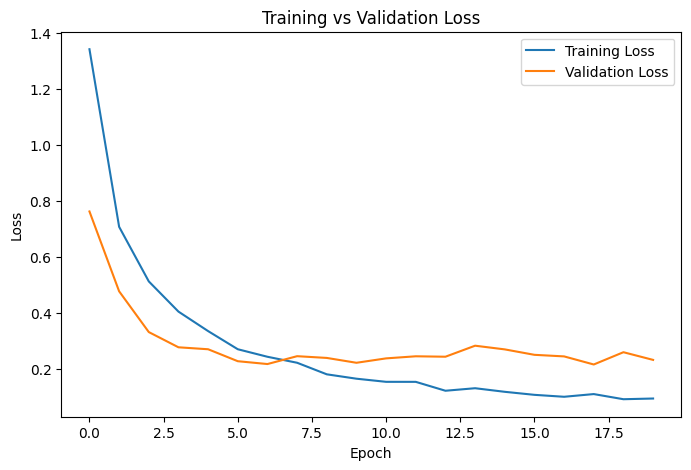

In [35]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

4.6: Evaluate on test data

In [37]:
model.eval()
test_correct, test_total = 0, 0

# Plum related class names
class_names = [
    "Pepper__bell__Bacterial_spot",
    "Pepper__bell__healthy",
    "Plum_Bacterial_Blight_Augmented",
    "Plum_Both_Augmented",
    "Plum_Healthy_Augmented",
    "Plum_Rust_Fungus_Augmented",
    "Potato___Early_blight",
    "Potato___healthy",
    "Potato___Late_blight",
    "Tomato__Target_Spot",
    "Tomato__Tomato_mosaic_virus",
    "Tomato__Tomato_YellowLeaf__Curl_Virus",
    "Tomato_Bacterial_spot",
    "Tomato_Early_blight",
    "Tomato_healthy",
    "Tomato_Late_blight",
    "Tomato_Leaf_Mold",
    "Tomato_Septoria_leaf_spot",
    "Tomato_Spider_mites_Two_spotted_spider_mite"
]

# Counters for each class
class_correct = [0 for _ in range(len(class_names))]
class_total = [0 for _ in range(len(class_names))]

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        # Class-wise accuracy
        for i in range(len(labels)):
            label = labels[i]
            class_total[label] += 1
            if predicted[i] == label:
                class_correct[label] += 1


test_acc = 100 * test_correct / test_total
print(f"✅ Final Test Accuracy: {test_acc:.2f}%")

# Per-class accuracy
print("\n📊 Class-wise Accuracy:")
for i in range(len(class_names)):
    if class_total[i] > 0:
        acc = 100 * class_correct[i] / class_total[i]
        print(f"{class_names[i]:25s} — {acc:.2f}% ({class_correct[i]}/{class_total[i]})")
        


✅ Final Test Accuracy: 93.93%

📊 Class-wise Accuracy:
Pepper__bell__Bacterial_spot — 92.96% (185/199)
Pepper__bell__healthy     — 99.32% (293/295)
Plum_Bacterial_Blight_Augmented — 87.95% (73/83)
Plum_Both_Augmented       — 94.32% (83/88)
Plum_Healthy_Augmented    — 95.92% (94/98)
Plum_Rust_Fungus_Augmented — 96.53% (195/202)
Potato___Early_blight     — 96.50% (193/200)
Potato___healthy          — 96.50% (193/200)
Potato___Late_blight      — 56.67% (17/30)
Tomato__Target_Spot       — 93.65% (398/425)
Tomato__Tomato_mosaic_virus — 80.50% (161/200)
Tomato__Tomato_YellowLeaf__Curl_Virus — 86.61% (330/381)
Tomato_Bacterial_spot     — 93.16% (177/190)
Tomato_Early_blight       — 91.81% (325/354)
Tomato_healthy            — 96.72% (324/335)
Tomato_Late_blight        — 87.86% (246/280)
Tomato_Leaf_Mold          — 99.22% (636/641)
Tomato_Septoria_leaf_spot — 98.65% (73/74)
Tomato_Spider_mites_Two_spotted_spider_mite — 100.00% (318/318)
